***Now we have to do the preprocessing part of our dataset***

**Importing all necessary libraries**

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('E_Comm_cleaned.csv')

In [4]:
data.sample(5)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
3042,53043,0,22.0,Phone,3,36.0,card,Female,4.0,4,Fashion,3,Divorced,5,0,22.0,1.0,2.0,1.0,250.04
5604,55605,1,20.0,Phone,1,14.0,COD,Male,4.0,4,Phone,3,Married,10,0,12.0,7.0,10.0,9.0,148.39
352,50353,0,23.0,Computer,2,9.0,card,Male,2.0,3,Others,4,Divorced,2,0,11.0,0.0,10.0,7.0,282.00
1502,51503,0,30.0,Phone,1,15.0,card,Female,3.0,4,Phone,4,Married,5,1,20.0,1.0,1.0,0.0,133.46
1576,51577,0,15.0,Phone,1,10.0,COD,Male,2.0,3,Others,1,Married,2,0,0.0,0.0,11.0,15.0,292.32


In [5]:
cat_cols = data.select_dtypes(include=['object']).columns
num_cols = data.select_dtypes(include=['int64','float64']).columns

cat_cols, num_cols

(Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
        'PreferedOrderCat', 'MaritalStatus'],
       dtype='object'),
 Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
        'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
        'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
        'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'],
       dtype='object'))

### Remove Outliers

In [6]:
cols_to_clip = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'NumberOfDeviceRegistered', 'NumberOfAddress',
    'OrderAmountHikeFromlastYear', 'OrderCount',
    'DaySinceLastOrder', 'CashbackAmount', 'CouponUsed'
]

for col in cols_to_clip:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Special cases from your code:
    if col == 'DaySinceLastOrder':
        data[col] = np.clip(data[col], lower, 20)
    elif col in ['HourSpendOnApp', 'NumberOfDeviceRegistered']:
        data[col] = np.clip(data[col], 0, upper)
    else:
        data[col] = np.clip(data[col], lower, upper)

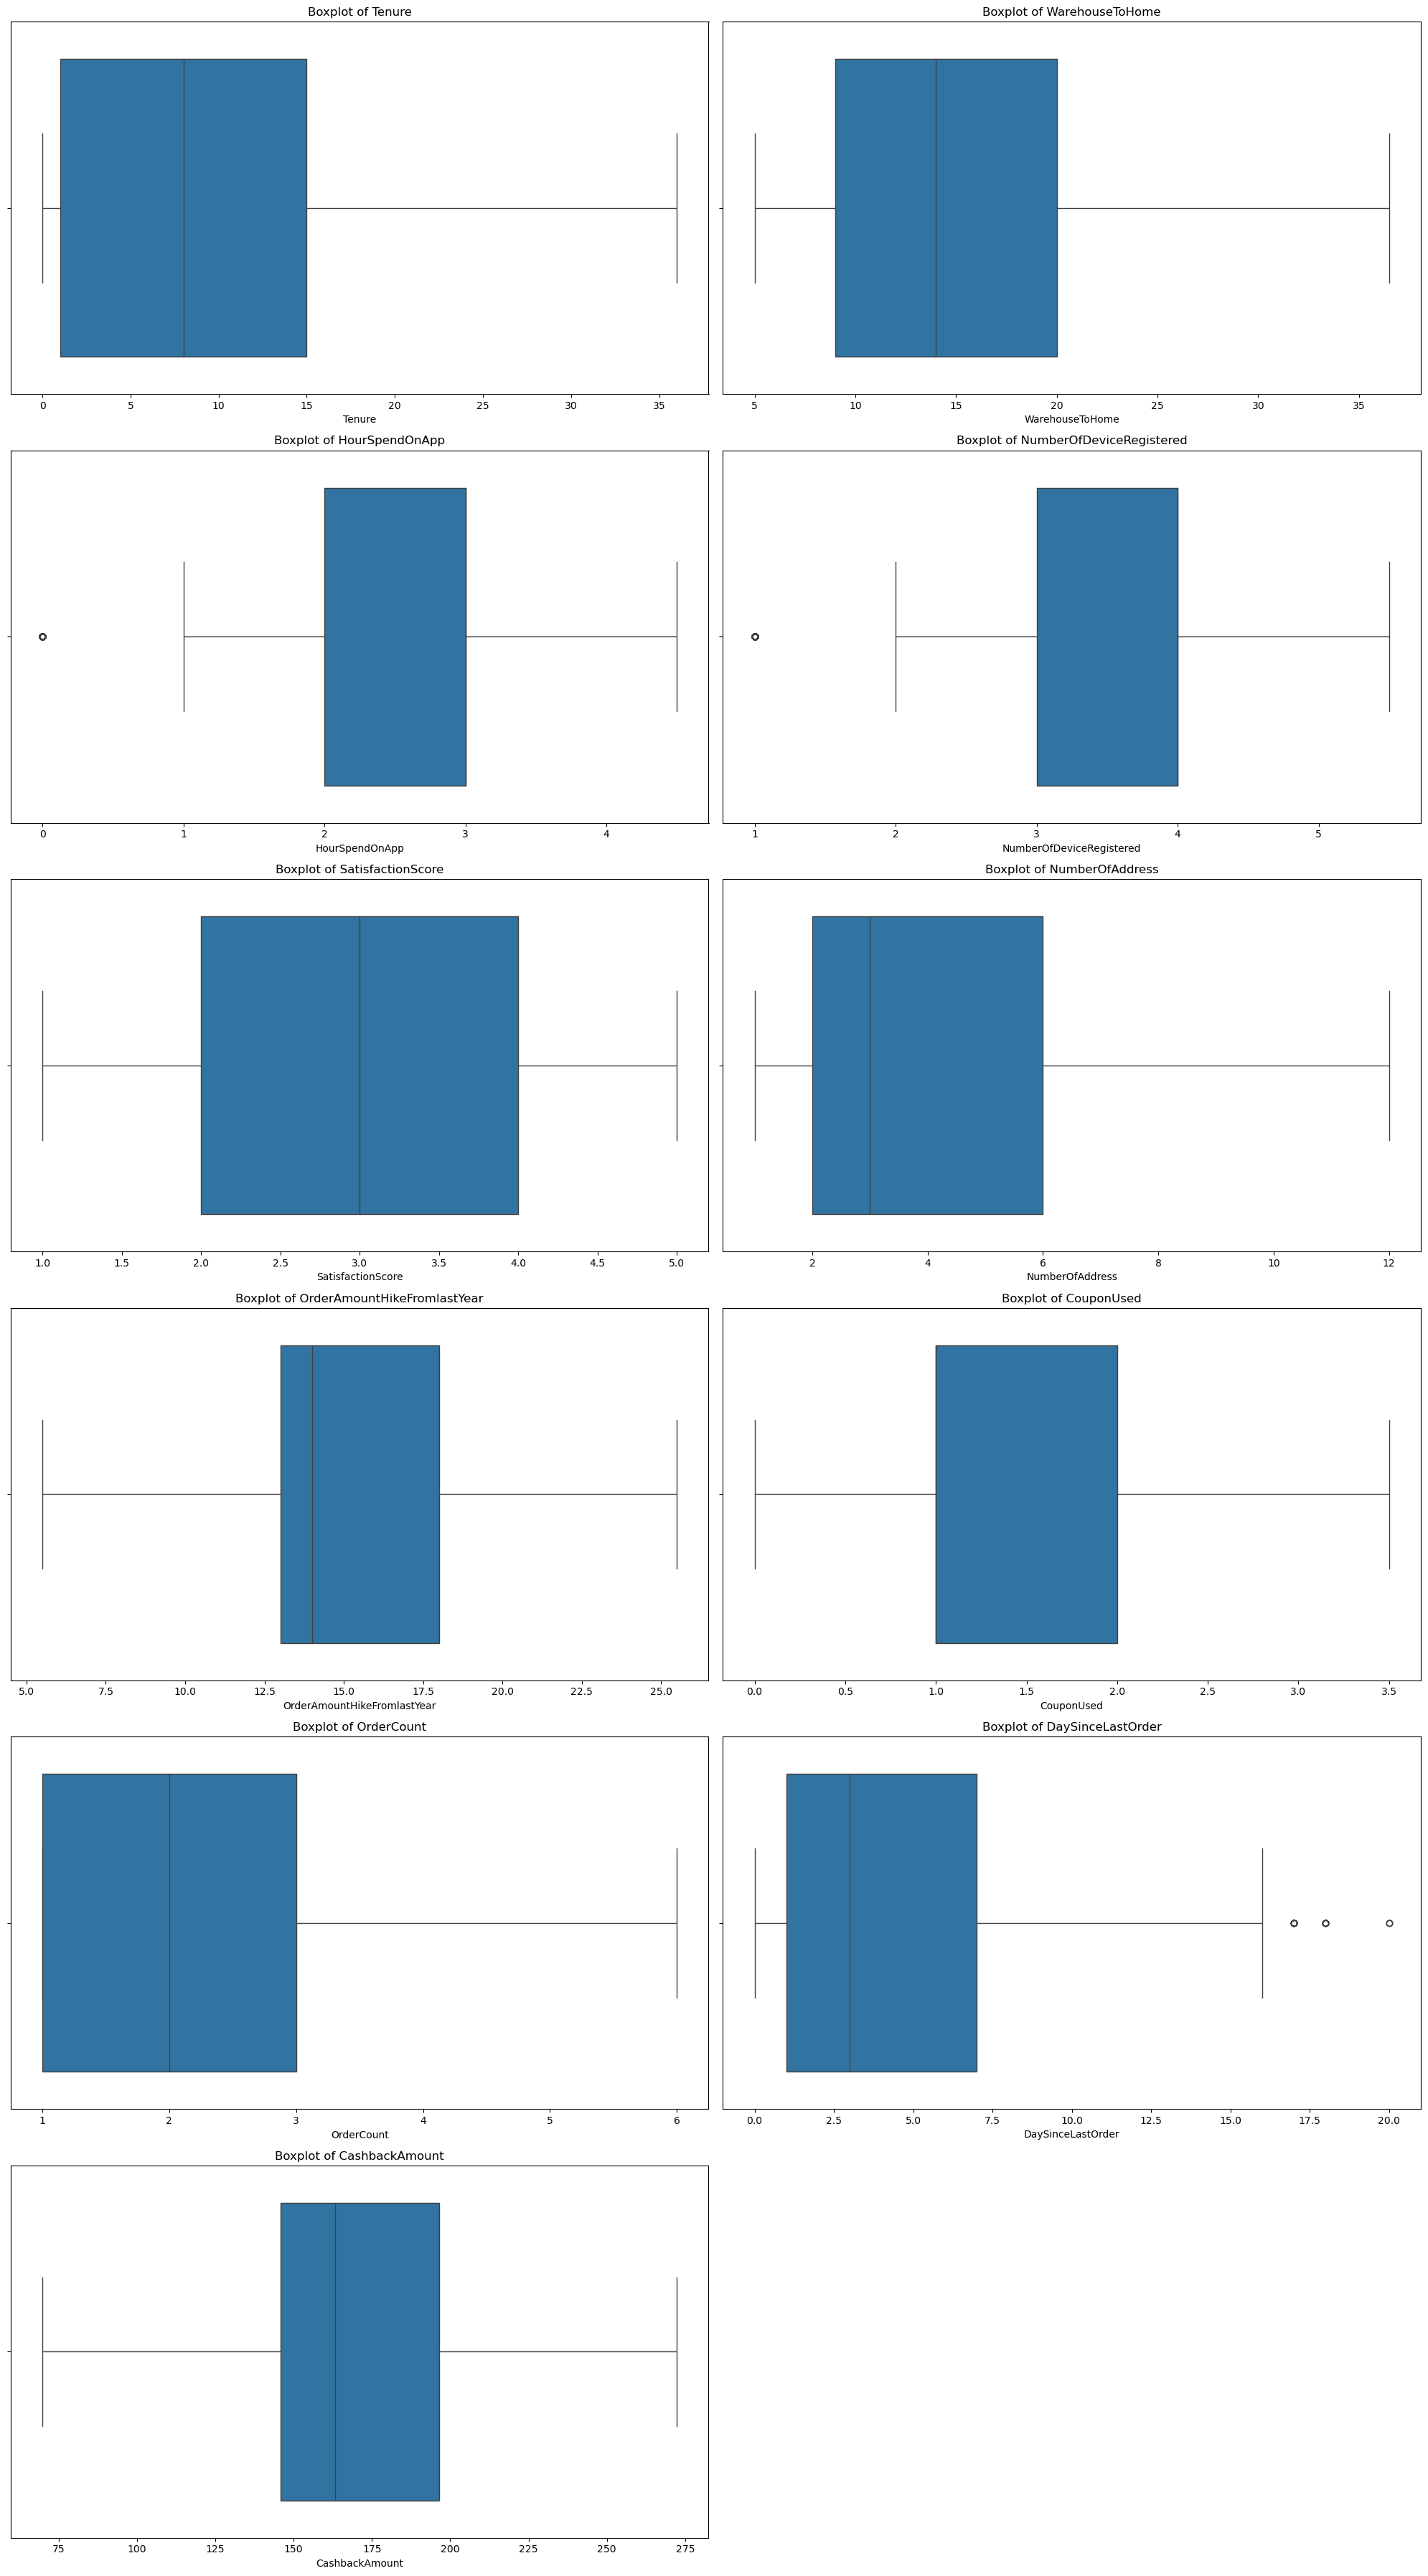

In [7]:
skip_cols = ['CustomerID', 'Churn', 'Complain', 'CityTier']

# number of numerical columns
plot_cols = [col for col in num_cols if col not in skip_cols]
n = len(plot_cols)

# create subplot grid
rows = math.ceil(n / 2) 
cols = 2

plt.figure(figsize=(20, 6 * rows))

for i, col in enumerate(plot_cols, 1):
    if col in skip_cols:
        continue
    plt.subplot(rows, cols, i)
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()

plt.show()

In [8]:
cat_cols

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')

In [9]:
data[cat_cols]

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
0,Phone,card,Female,Laptop & Accessory,Single
1,Phone,UPI,Male,Phone,Single
2,Phone,card,Male,Phone,Single
3,Phone,card,Male,Laptop & Accessory,Single
4,Phone,card,Male,Phone,Single
...,...,...,...,...,...
5625,Computer,card,Male,Laptop & Accessory,Married
5626,Phone,card,Male,Fashion,Married
5627,Phone,card,Male,Laptop & Accessory,Married
5628,Computer,card,Male,Laptop & Accessory,Married


In [10]:
data.to_csv('Modelling_data.csv', index=False)